# DineWise: Predictive Restaurant Success & Recommendation System

This notebook implements the machine learning pipeline for the **DineWise** project. It is structured into three main modules:
1. **Module 1: Success Predictor (Supervised Learning)** - Regression models to predict restaurant aggregate ratings.
2. **Module 2: Geospatial Spot Analysis (Unsupervised Learning)** - K-Means clustering to discover restaurant hubs.
3. **Module 3: Cuisine Recommender (NLP)** - Text TF-IDF cosine similarity to recommend restaurants based on cuisine profile similarity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("Required ML libraries imported successfully.")

Required ML libraries imported successfully.


## Phase 1: Setup and Preprocessing

Let's load the dataset, drop redundant identifiers, handle missing values, and prepare the dataset for machine learning.

In [2]:
# Load the dataset
df = pd.read_csv('Dataset.csv')
print(f"Dataset Loaded. Shape: {df.shape}")

# Drop unnecessary columns that are identifiers or have near-zero variance
cols_to_drop = ['Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.2', 'Restaurant ID', 'Restaurant Name', 
                'Country Code', 'Address', 'Locality Verbose', 'Currency', 'Switch to order menu']
df_ml = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Fill missing cuisines with 'Unknown'
df_ml['Cuisines'] = df_ml['Cuisines'].fillna('Unknown')
print(f"Dataset shape after initial drops: {df_ml.shape}")

Dataset Loaded. Shape: (9551, 24)
Dataset shape after initial drops: (9551, 14)


### Feature Engineering for Cuisines (Multi-label Binarization)

Since `Cuisines` is a comma-separated string (e.g., "French, Japanese, Desserts"), standard one-hot encoding on the column directly won't work. We need to split the cuisines and represent them as binary features. We will select the top 30 most common cuisines to keep dimensionality manageable.

In [3]:
# Extract all unique cuisines and determine frequency counts
cuisine_counts = df_ml['Cuisines'].str.split(',').explode().str.strip().value_counts()
top_30_cuisines = cuisine_counts.head(30).index.tolist()

print(f"Total unique cuisines detected: {len(cuisine_counts)}")
print(f"Top 10 cuisines by frequency:\n{cuisine_counts.head(10)}")

# Create binary columns for the top 30 cuisines
for cuisine in top_30_cuisines:
    df_ml[f'Cuisine_{cuisine}'] = df_ml['Cuisines'].apply(lambda x: 1 if cuisine in [c.strip() for c in x.split(',')] else 0)

print(f"\nCreated {len(top_30_cuisines)} binary cuisine features. New dataframe shape: {df_ml.shape}")

Total unique cuisines detected: 146
Top 10 cuisines by frequency:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64



Created 30 binary cuisine features. New dataframe shape: (9551, 44)


### Encode Binary and Categorical Columns

Convert binary yes/no columns (`Has Table booking`, `Has Online delivery`, `Is delivering now`) to numerical `0` and `1` values.

In [4]:
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now']
for col in binary_cols:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].map({'Yes': 1, 'No': 0})

print("Binary columns successfully encoded:")
print(df_ml[binary_cols].head())

Binary columns successfully encoded:
   Has Table booking  Has Online delivery  Is delivering now
0                  1                    0                  0
1                  1                    0                  0
2                  1                    0                  0
3                  0                    0                  0
4                  1                    0                  0


## Phase 2: Module 1 - Success Predictor (Supervised Learning)

We want to predict a restaurant's rating (`Aggregate rating`) using features like price range, average cost, votes, and cuisine type.
Let's first define our feature set $X$ and target $y$, perform train-test splits, and scale numerical values.

In [5]:
# Select features for regression modeling
numeric_features = ['Average Cost for two', 'Price range', 'Votes', 'Has Table booking', 'Has Online delivery', 'Is delivering now']
cuisine_features = [f'Cuisine_{c}' for c in top_30_cuisines]
features = numeric_features + cuisine_features

X = df_ml[features]
y = df_ml['Aggregate rating']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}, Testing set size: {X_test.shape[0]}")

# Scale numeric columns to handle differences in scales (e.g. Cost in hundreds vs binary booking fields)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])
print("Numerical features scaled successfully.")

Training set size: 7640, Testing set size: 1911
Numerical features scaled successfully.


### Model Training & Evaluation

We will train three models:
1. Linear Regression (Baseline)
2. Random Forest Regressor (Ensemble)
3. Gradient Boosting Regressor (Ensemble)

We will compare their performance using MSE (Mean Squared Error), MAE (Mean Absolute Error), and $R^2$ Score.

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model      MSE      MAE  R2 Score
Linear Regression 1.594672 1.050361  0.299387
    Random Forest 0.107172 0.214879  0.952915
Gradient Boosting 0.096730 0.207615  0.957502


### Visualizing Model Performance Comparisons

Let's visualize the performance differences to choose our best production model.

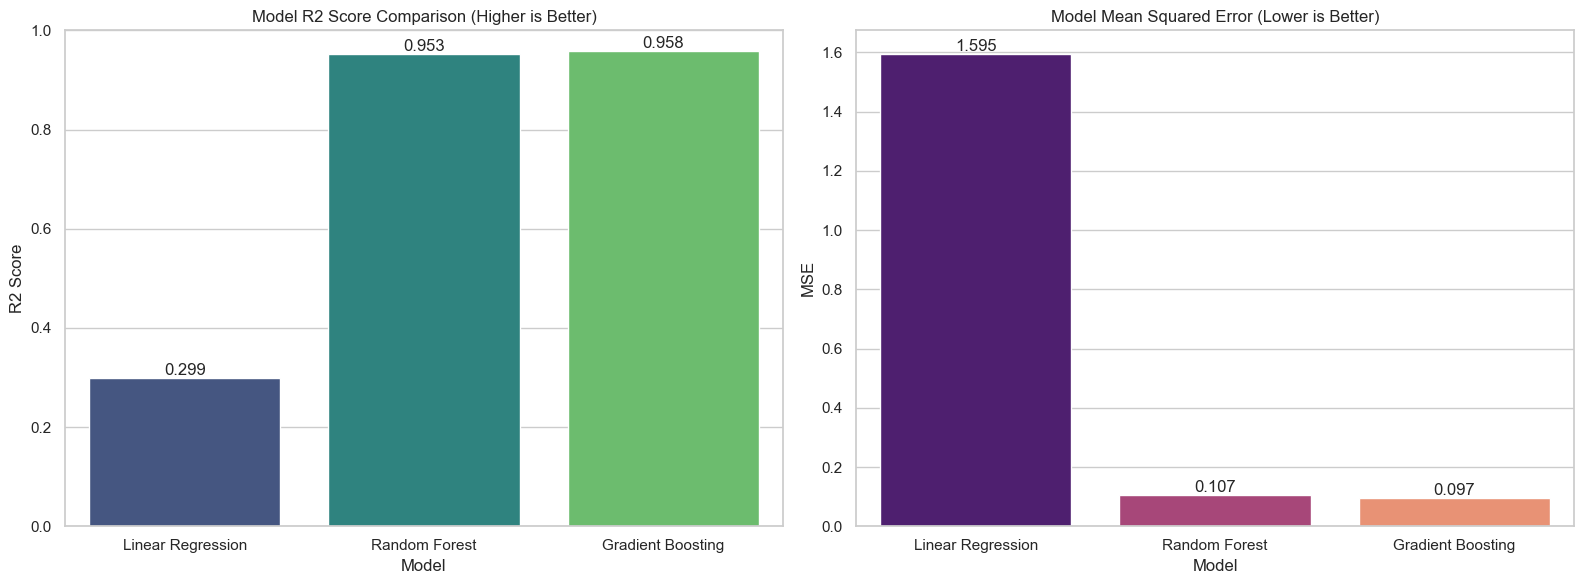

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Score Plot
sns.barplot(x="Model", y="R2 Score", data=results_df, ax=axes[0], palette="viridis")
axes[0].set_title("Model R2 Score Comparison (Higher is Better)")
axes[0].set_ylim(0, 1.0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f')

# MSE Plot
sns.barplot(x="Model", y="MSE", data=results_df, ax=axes[1], palette="magma")
axes[1].set_title("Model Mean Squared Error (Lower is Better)")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

### Analyzing Feature Importance

To understand what features drive a restaurant's success, we will plot the feature importances from our best ensemble model.

Best Performing Model: Gradient Boosting (R2 = 0.9575)


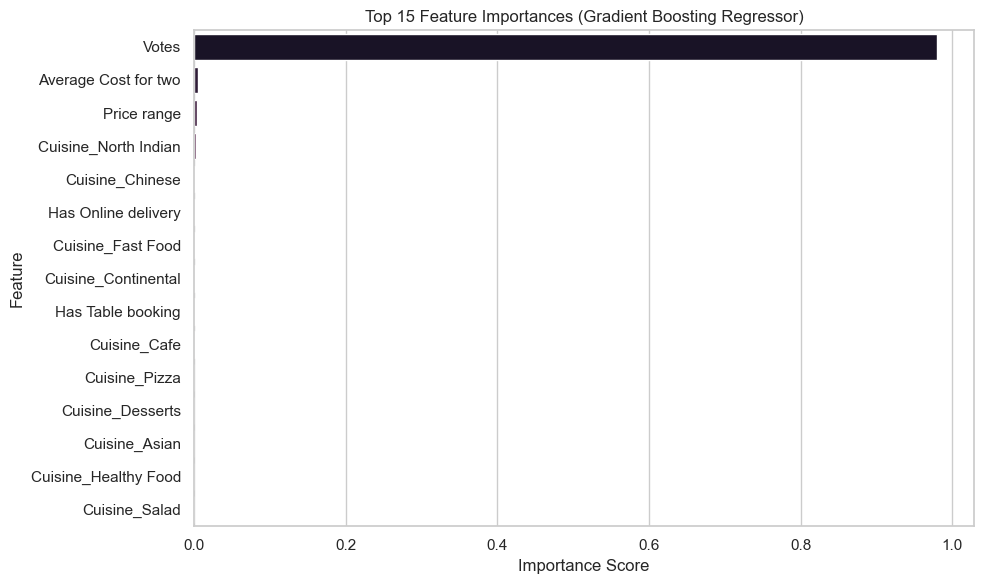

In [8]:
# Identify best model based on R2 Score
best_row = results_df.loc[results_df['R2 Score'].idxmax()]
best_model_name = best_row['Model']
best_model = trained_models[best_model_name]
print(f"Best Performing Model: {best_model_name} (R2 = {best_row['R2 Score']:.4f})")

importances = best_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
sns.barplot(x="Importance", y="Feature", data=feature_imp_df.head(15), palette="rocket")
plt.title(f"Top 15 Feature Importances ({best_model_name} Regressor)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Phase 3: Module 2 - Geospatial Hotspots (Unsupervised Learning)

For restaurant developers, identifying geographic clusters of existing restaurants can pinpoint target markets or high-density zones. We'll use K-Means clustering on the `Latitude` and `Longitude` values. Let's filter for New Delhi, which has the highest density of restaurants in this dataset.

Number of restaurants in New Delhi for clustering: 5240


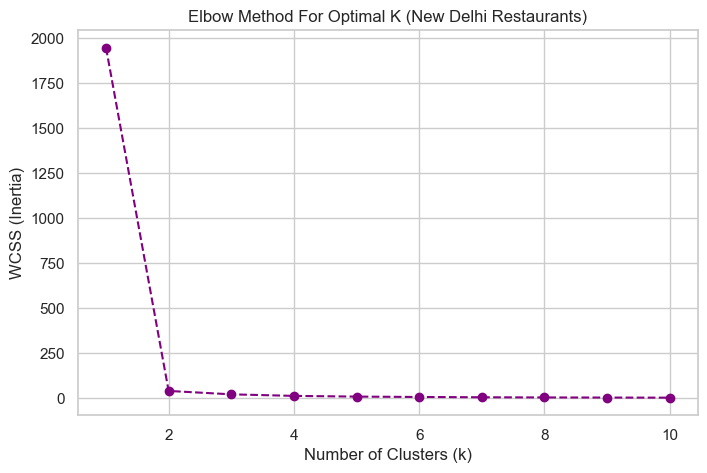

In [9]:
# Filter for New Delhi, ensuring coordinates are non-zero
delhi_df = df[(df['City'] == 'New Delhi') & (df['Longitude'] != 0) & (df['Latitude'] != 0)].copy()
print(f"Number of restaurants in New Delhi for clustering: {delhi_df.shape[0]}")

# Use Elbow Method to determine optimal number of clusters
coords = delhi_df[['Longitude', 'Latitude']]
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coords)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', color='purple', linestyle='--')
plt.title('Elbow Method For Optimal K (New Delhi Restaurants)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()

### Fit K-Means and Visualize Clusters

Based on the elbow plot, we select an optimal $k=5$ clusters to segment New Delhi's dining hubs and plot them. Centroids are plotted as black 'X' marks.

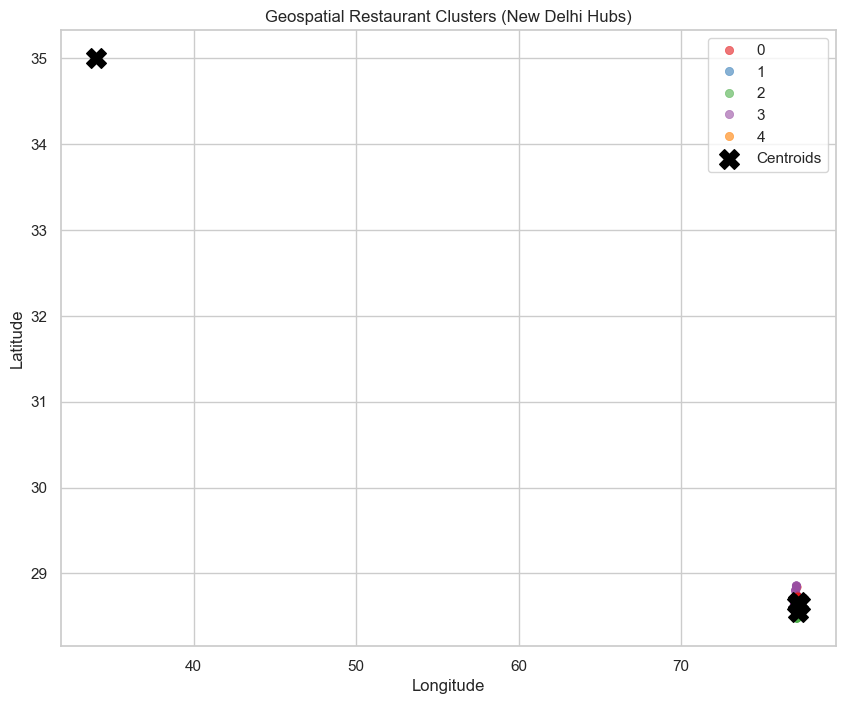

Cluster Profiles:
Cluster 0: Restaurants = 1275, Avg Cost for Two = 636.7, Avg Rating = 2.72
Cluster 1: Restaurants = 1, Avg Cost for Two = 800.0, Avg Rating = 0.00
Cluster 2: Restaurants = 2076, Avg Cost for Two = 724.1, Avg Rating = 2.67
Cluster 3: Restaurants = 1116, Avg Cost for Two = 472.3, Avg Rating = 2.28
Cluster 4: Restaurants = 772, Avg Cost for Two = 416.8, Avg Rating = 2.01


In [10]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
delhi_df['Cluster'] = kmeans.fit_predict(coords)

# Plot the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Longitude', y='Latitude', hue='Cluster', data=delhi_df, palette='Set1', alpha=0.6, edgecolor=None)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title('Geospatial Restaurant Clusters (New Delhi Hubs)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

# Analyze cluster profiles
print("Cluster Profiles:")
for i in range(optimal_k):
    cluster_data = delhi_df[delhi_df['Cluster'] == i]
    print(f"Cluster {i}: Restaurants = {cluster_data.shape[0]}, Avg Cost for Two = {cluster_data['Average Cost for two'].mean():.1f}, Avg Rating = {cluster_data['Aggregate rating'].mean():.2f}")

## Phase 4: Module 3 - Content-Based Cuisine Recommender (NLP)

To recommend similar restaurants to a user, we can build a similarity engine. We'll represent each restaurant's profile using its `Cuisines` text and find matching restaurants using TF-IDF Vectorization and Cosine Similarity.

In [11]:
# Drop duplicates for recommendation to ensure name uniqueness
rec_df = df[['Restaurant Name', 'Cuisines', 'Aggregate rating', 'Price range', 'City']].drop_duplicates(subset=['Restaurant Name']).copy()
rec_df['Cuisines'] = rec_df['Cuisines'].fillna('Unknown')

# Initialize TF-IDF Vectorizer to convert cuisines string to TF-IDF features
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(rec_df['Cuisines'])

print(f"TF-IDF Matrix shape (Restaurants, Unique Cuisine tokens): {tfidf_matrix.shape}")

# Compute Cosine Similarity Matrix between all vectors
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine similarity matrix computed.")

TF-IDF Matrix shape (Restaurants, Unique Cuisine tokens): (7446, 149)


Cosine similarity matrix computed.


### Recommendation Utility Function

We build `recommend_restaurants` to take a restaurant name, look up its index, calculate similarity values, and display the top $N$ most similar restaurants.

In [12]:
# Construct a reverse map of indices and restaurant names
indices = pd.Series(rec_df.index, index=rec_df['Restaurant Name'].str.lower()).drop_duplicates()

def recommend_restaurants(name, top_n=5):
    name_lower = name.lower()
    if name_lower not in indices:
        return f"Restaurant '{name}' not found in the dataset."
    
    # Get the index of the restaurant
    idx = indices[name_lower]
    
    # If there are duplicate names mapping to multiple indices, take the first one
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
        
    # Get similarity scores of all restaurants with that restaurant
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort the restaurants based on similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get the scores of the top N most similar restaurants (excluding itself)
    sim_scores = [item for item in sim_scores if item[0] != idx][:top_n]
    
    # Get the restaurant indices
    restaurant_indices = [i[0] for i in sim_scores]
    similarity_values = [i[1] for i in sim_scores]
    
    # Return the top N most similar restaurants
    recommendations = rec_df.iloc[restaurant_indices].copy()
    recommendations['Similarity Score'] = similarity_values
    return recommendations[['Restaurant Name', 'Cuisines', 'Aggregate rating', 'Price range', 'City', 'Similarity Score']]

# Test recommendations
print("Testing Recommendations for 'Le Petit Souffle':")
print(recommend_restaurants('Le Petit Souffle', top_n=5))

Testing Recommendations for 'Le Petit Souffle':
            Restaurant Name          Cuisines  Aggregate rating  Price range  \
4993        Tokyo Mon Amour  Japanese, French               3.1            4   
70        Paris 6 Classique            French               3.4            4   
259                  Django            French               4.3            3   
460                    Jaan            French               3.8            4   
461   Rhubarb Le Restaurant            French               3.9            4   

            City  Similarity Score  
4993   New Delhi          0.909100  
70    S��o Paulo          0.718754  
259   Des Moines          0.718754  
460    Singapore          0.718754  
461    Singapore          0.718754  
